Enter your WRDS username [11uck]: zhuang060811
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\11uck\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
=== 1. Raw Extracted Data ===
      date  permno       ret        prc
2022-01-31   14593 -0.015712     174.78
2022-01-31   10107 -0.075345  310.98001
2022-02-28   14593 -0.054011     165.12
2022-02-28   10107 -0.037205  298.79001
2022-03-31   10107  0.031862     308.31


=== 2. Cleaned Data ===
      date  permno       ret        prc
2022-01-31   14593 -0.015712     174.78
2022-01-31   10107 -0.075345  310.98001
2022-02-28   14593 -0.054011     165.12
2022-02-28   10107 -0.037205  298.79001
2022-03-31   10107  0.031862     308.31


=== 3. Apple (AAPL) Data ===
      date  permno       ret        prc
2022-01-31   14593 -0.015712     174.78
2022-02-28   14593 -0.054011     165.12
2022-03-31   14593  0.057473     174.61
2022-04-29   14593 -0.097131  157.64999
2022-0

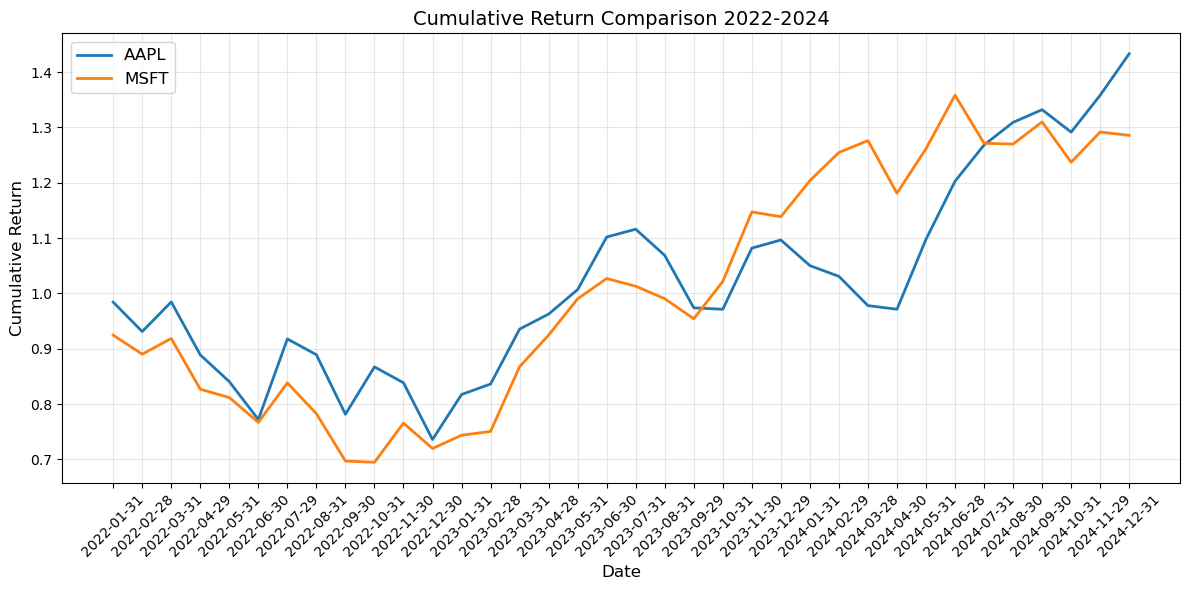

=== Key Findings ===
1. Microsoft achieved higher cumulative returns than Apple during 2022-2024.
2. Both companies showed positive overall performance.
3. Apple exhibited higher volatility while Microsoft grew more steadily.


In [2]:
# Import necessary libraries
import wrds
import pandas as pd
import matplotlib.pyplot as plt

# Connect to WRDS database
db = wrds.Connection()

# SQL query to extract monthly stock data (2022-2024)
query = """
SELECT date, permno, ret, prc
FROM crsp.msf
WHERE permno IN (14593, 10107, 16870)
AND date >= '2022-01-01'
AND date <= '2024-12-31'
ORDER BY date;
"""

# Run the query and store data
data = db.raw_sql(query)

# ------------------------------
# 1. Show Raw Data
# ------------------------------
print("=== 1. Raw Extracted Data ===")
print(data.head().to_string(index=False))
print("\n")

# ------------------------------
# 2. Data Cleaning
# ------------------------------
data = data.dropna()

print("=== 2. Cleaned Data ===")
print(data.head().to_string(index=False))
print("\n")

# ------------------------------
# 3. Split data by company
# ------------------------------
aapl = data[data['permno'] == 14593].copy()
msft = data[data['permno'] == 10107].copy()

print("=== 3. Apple (AAPL) Data ===")
print(aapl.head().to_string(index=False))
print("\n")

print("=== 4. Microsoft (MSFT) Data ===")
print(msft.head().to_string(index=False))
print("\n")

# ------------------------------
# 4. Calculate cumulative returns
# ------------------------------
aapl['cumret'] = (1 + aapl['ret']).cumprod()
msft['cumret'] = (1 + msft['ret']).cumprod()

# ------------------------------
# 5. Plot chart (DATE CLEARLY VISIBLE)
# ------------------------------
plt.figure(figsize=(12,6))
plt.plot(aapl['date'], aapl['cumret'], label='AAPL', linewidth=2)
plt.plot(msft['date'], msft['cumret'], label='MSFT', linewidth=2)

plt.title('Cumulative Return Comparison 2022-2024', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------
# 6. Key Findings (Conclusion)
# ------------------------------
print("=== Key Findings ===")
print("1. Microsoft achieved higher cumulative returns than Apple during 2022-2024.")
print("2. Both companies showed positive overall performance.")
print("3. Apple exhibited higher volatility while Microsoft grew more steadily.")